# 2.3 Segmentation — Full-Stack Test (441 planes, z 60–500)

Full-stack QC of the 2D Sauvola segmentation produced in `2_1_segmentation.ipynb`
(`savola_3D_image`, per-plane, window 21, k=0.15). This notebook **reads the saved segmentation**
(no recomputation) and QCs it per depth zone from `zone_samples.csv`, reporting **mean ± SD over
each zone's `z_start:z_end` range** 

Two metrics per zone:
- **2D component count** — connected components per plane (`count_connexin_plaques`). These are
  cross-sections, not unique 3D plaques.
- **Foreground fraction** — fraction of pixels segmented per plane.


In [25]:
from pathlib import Path
import sys
import contextlib, os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io, img_as_float
from skimage.exposure import rescale_intensity

BASE_DIR = Path.cwd().parent
RESULTS_DIR = BASE_DIR / 'results' / 'segmented'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DISP_VMIN = 0           # constant grayscale display range, fixed across ALL planes so that
DISP_VMAX = 10000       # depth comparisons are visually consistent (tune to taste)
MIN_DISTANCE = 2        # peak_local_max min distance (~connexin size / 2, matches 2_1)
REGION_Z0, REGION_Z1 = 90, 100  # z-range highlighted in Sections 5 & 7

sys.path.append(str(BASE_DIR / 'src'))
from quantification import count_connexin_plaques, count_connexin_plaques_within_plaque

## 0. Load zone samples

In [26]:
# crop bounds mirror 2_1: preprocessed_image[60:501, :, 23:999]
Z0, Z1 = 60, 501   # z 60-500 (441 planes)
X0, X1 = 23, 999   # x -> 976 px, aligned to the nuclei frame

zone_samples_path = BASE_DIR / 'data' / 'zone_samples.csv'
zone_samples = pd.read_csv(zone_samples_path)
print(f"Loaded {len(zone_samples)} zones from {zone_samples_path}")

# shift the z-based sample regions into the cropped (60:501) frame and save
cropped = zone_samples.copy()
cropped['z_start'] = cropped['z_start'].clip(Z0, Z1) - Z0
cropped['z_end'] = cropped['z_end'].clip(Z0, Z1) - Z0
cropped['sample_plane'] = cropped['sample_plane'] - Z0
# drop zones whose sample plane falls outside the cropped stack (e.g. plateau)
cropped = cropped[cropped['sample_plane'].between(0, (Z1 - Z0) - 1)].reset_index(drop=True)

cropped_path = BASE_DIR / 'data' / 'cropped_sample_regions.csv'
cropped.to_csv(cropped_path, index=False)
print(f"Saved {len(cropped)} cropped zones -> {cropped_path}")

# use the cropped regions for the rest of the notebook
zone_samples = cropped
zone_samples

Loaded 9 zones from /home/rck292/Project/data/zone_samples.csv
Saved 8 cropped zones -> /home/rck292/Project/data/cropped_sample_regions.csv


,zone_number,zone_label,z_start,z_end,sample_plane,sample_plane_intensity
0,2,rising-1,0,41,7,515.66
1,3,rising-2,41,109,75,2222.98
2,4,rising-3,109,176,142,5335.92
3,5,rising-4,176,244,210,9162.24
4,6,rising-5,244,312,278,11514.37
5,7,falling-1,312,357,334,11384.69
6,8,falling-2,357,403,380,9689.39
7,9,falling-3,403,441,426,7286.28


## 1. Load deconvolved image + segmentation

`seg_path` should point at the segmentation you want to QC — adjust it if you saved different
Sauvola parameters in `2_1_segmentation.ipynb`.

In [ ]:
deconv_path = BASE_DIR / 'data' / 'preprocessed' / 'background_removed_and_deconvolved_img.tiff'
seg_path = BASE_DIR / 'data' / 'segmented' / 'binary_sauvola3d_w9_21_21_k0_15.tiff'

deconvolved = io.imread(deconv_path)
# match the z/x crop applied in 2_1 before segmentation (60:501, 23:999)
deconvolved = deconvolved[Z0:Z1, :, X0:X1]
seg = io.imread(seg_path) > 0  # ubyte 0/255 -> bool foreground

print(f"Deconvolved: shape={deconvolved.shape}, dtype={deconvolved.dtype}")
print(f"Segmentation: shape={seg.shape}, dtype=bool (from {seg_path.name})")

if seg.shape != deconvolved.shape:
    print(f"WARNING: segmentation shape {seg.shape} != deconvolved shape {deconvolved.shape}")

n_planes = seg.shape[0]
oor = zone_samples[~zone_samples['sample_plane'].between(0, n_planes - 1)]
print("All sample planes in range." if not len(oor) else f"WARNING: out-of-range planes:\n{oor}")

## 2. QC helpers

In [28]:
def plot_zone_overlay_grid(image, binary, zone_df, ncols=4):
    """Per zone: the sample_plane grayscale (constant display range) with the segmentation
    boundary drawn as a red contour."""
    n = len(zone_df)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)
    for i, (_, row) in enumerate(zone_df.iterrows()):
        ax = axes[i // ncols, i % ncols]
        p = int(row['sample_plane'])
        ax.imshow(image[p], cmap='gray', vmin=DISP_VMIN, vmax=DISP_VMAX)
        ax.contour(binary[p], [0.5], colors='r', linewidths=0.4)
        ax.set_title(f"{row['zone_label']} (plane {p})")
        ax.axis('off')
    for j in range(n, nrows * ncols):
        axes[j // ncols, j % ncols].axis('off')
    fig.suptitle('Segmentation overlay — sample plane per zone')
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / 'zone_overlay_grid.png', dpi=150, bbox_inches='tight')
    plt.show()


def format_mean_sd(mean, sd):
    if np.isnan(mean):
        return "n/a"
    if np.isnan(sd):
        return f"{mean:.3g}"
    return f"{mean:.3g} ± {sd:.3g}"


def zone_segmentation_stats(binary, zone_df):
    """Per zone, over every plane in [z_start, z_end): mean +/- SD of the 2D component count
    and of the foreground area fraction."""
    n_planes = binary.shape[0]
    rows = []
    for _, row in zone_df.iterrows():
        z0, z1 = int(row['z_start']), min(int(row['z_end']), n_planes)
        counts, fracs = [], []
        for z in range(z0, z1):
            counts.append(int(count_connexin_plaques(binary[z])[0]))
            fracs.append(float(binary[z].mean()))
        counts, fracs = np.asarray(counts), np.asarray(fracs)
        rows.append({
            'zone_number': row['zone_number'],
            'zone_label': row['zone_label'],
            'z_range': f"{int(row['z_start'])}:{int(row['z_end'])}",
            'count_mean': counts.mean() if counts.size else np.nan,
            'count_sd': counts.std(ddof=1) if counts.size > 1 else np.nan,
            'fgfrac_mean': fracs.mean() if fracs.size else np.nan,
            'fgfrac_sd': fracs.std(ddof=1) if fracs.size > 1 else np.nan,
        })
    return pd.DataFrame(rows)

## 3. Per-zone overlay QC

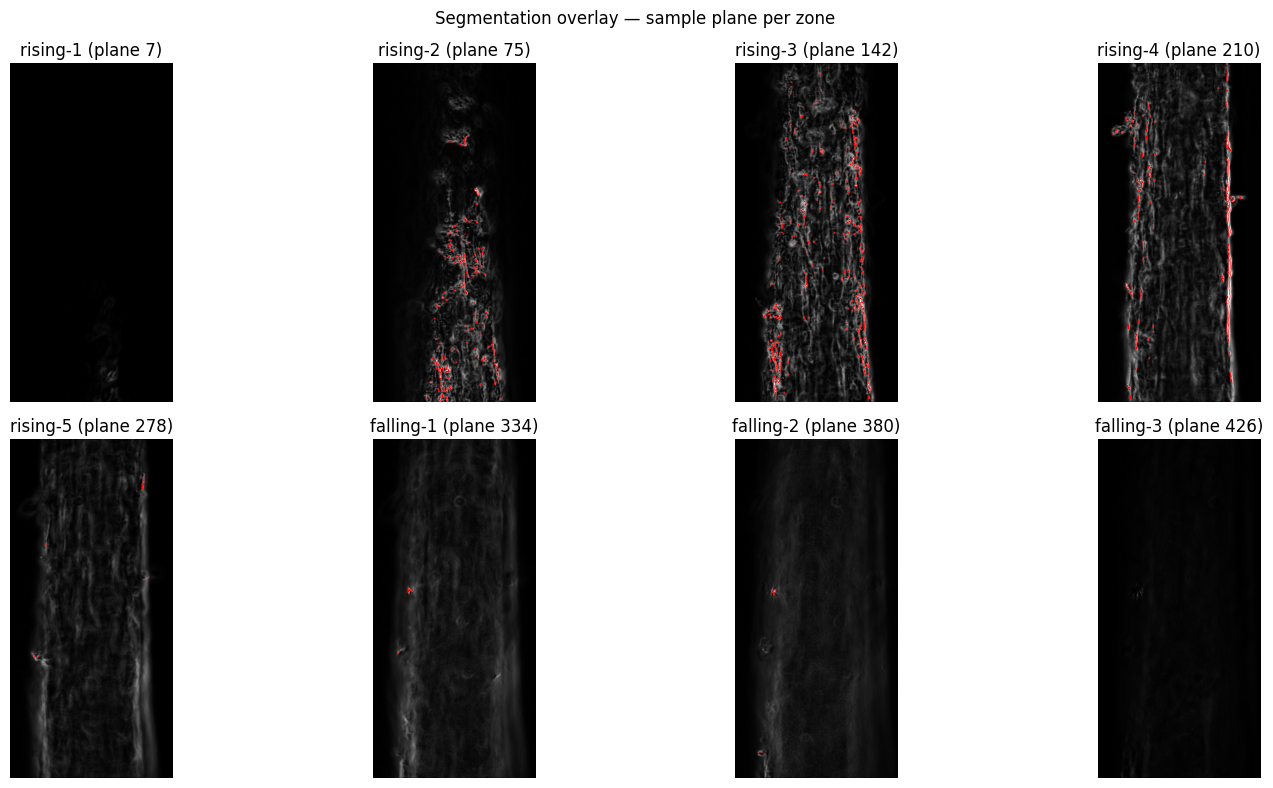

In [29]:
plot_zone_overlay_grid(deconvolved, seg, zone_samples)

## 4. Per-zone segmentation stats (mean ± SD over each zone's z-range)

In [30]:
seg_stats = zone_segmentation_stats(seg, zone_samples)

seg_display = pd.DataFrame({
    'zone_label': seg_stats['zone_label'],
    'z_range': seg_stats['z_range'],
    'components/plane (mean ± SD)': [format_mean_sd(m, s) for m, s in zip(seg_stats['count_mean'], seg_stats['count_sd'])],
    'foreground fraction (mean ± SD)': [format_mean_sd(m, s) for m, s in zip(seg_stats['fgfrac_mean'], seg_stats['fgfrac_sd'])],
})
print("2D connected components and foreground fraction per plane, aggregated over each zone's z-range:")
seg_display

2D connected components and foreground fraction per plane, aggregated over each zone's z-range:


,zone_label,z_range,components/plane (mean ± SD),foreground fraction (mean ± SD)
0,rising-1,0:41,18.5 ± 26,0.000235 ± 0.000315
1,rising-2,41:109,283 ± 156,0.00426 ± 0.0028
2,rising-3,109:176,504 ± 107,0.00847 ± 0.000649
3,rising-4,176:244,206 ± 83.3,0.00715 ± 0.00238
4,rising-5,244:312,18.2 ± 17.1,0.000364 ± 0.000429
5,falling-1,312:357,9.13 ± 3,0.000129 ± 2.15e-05
6,falling-2,357:403,5.85 ± 1.81,0.000106 ± 3.49e-05
7,falling-3,403:441,0.921 ± 1.02,6.68e-06 ± 9.47e-06


## 5. Full-stack per-plane trend

Exposes depth-dependent dropout across the whole stack.

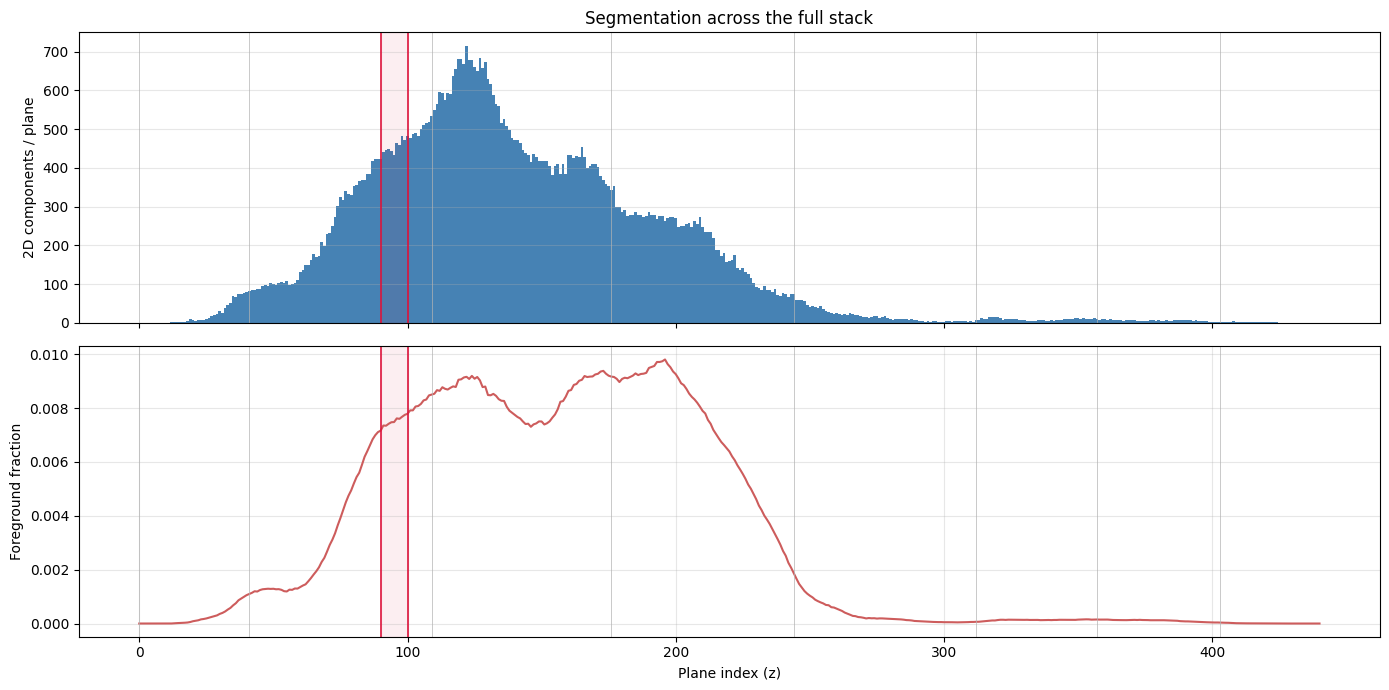

In [31]:
counts = np.array([count_connexin_plaques(seg[z])[0] for z in range(n_planes)])
fgfrac = np.array([seg[z].mean() for z in range(n_planes)])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax1.bar(range(n_planes), counts, width=1.0, color='steelblue', edgecolor='none')
ax1.set_ylabel('2D components / plane')
ax1.set_title('Segmentation across the full stack')
ax1.grid(axis='y', alpha=0.3)
ax2.plot(range(n_planes), fgfrac, color='indianred')
ax2.set_xlabel('Plane index (z)')
ax2.set_ylabel('Foreground fraction')
ax2.grid(alpha=0.3)

# shade zone boundaries for context
for _, row in zone_samples.iterrows():
    ax1.axvline(int(row['z_start']), color='0.7', lw=0.5)
    ax2.axvline(int(row['z_start']), color='0.7', lw=0.5)

# highlight the REGION_Z0:REGION_Z1 range (matches Section 7)
for a in (ax1, ax2):
    a.axvspan(REGION_Z0, REGION_Z1, color='crimson', alpha=0.07)
    a.axvline(REGION_Z0, color='crimson', lw=1.2)
    a.axvline(REGION_Z1, color='crimson', lw=1.2)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'fullstack_count_fgfrac.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Connexin peak count across all planes

An alternative count using `count_connexin_plaques_within_plaque` (peak detection via
`peak_local_max` restricted to the segmented foreground). Unlike the connected-component count,
it **splits touching plaques** into separate peaks, so peak counts are >= component counts where
plaques merge.

In [32]:
def plane_to_float01(plane):
    """Normalize a single plane to [0, 1] (peak_local_max's threshold_abs=0.05 assumes this range)."""
    return img_as_float(rescale_intensity(plane, out_range=(0, 1)))

peak_counts = np.zeros(n_planes, dtype=int)
with contextlib.redirect_stdout(open(os.devnull, 'w')):  # suppress the function's per-plane print
    for z in range(n_planes):
        img01 = plane_to_float01(deconvolved[z])
        _, peak_counts[z] = count_connexin_plaques_within_plaque(img01, seg[z], min_distance=MIN_DISTANCE)

print(f"Total 2D peak detections across all {n_planes} planes: {peak_counts.sum()}")
print("(per-plane 2D detections summed over z -- not unique 3D plaques)")

Total 2D peak detections across all 441 planes: 93366
(per-plane 2D detections summed over z -- not unique 3D plaques)


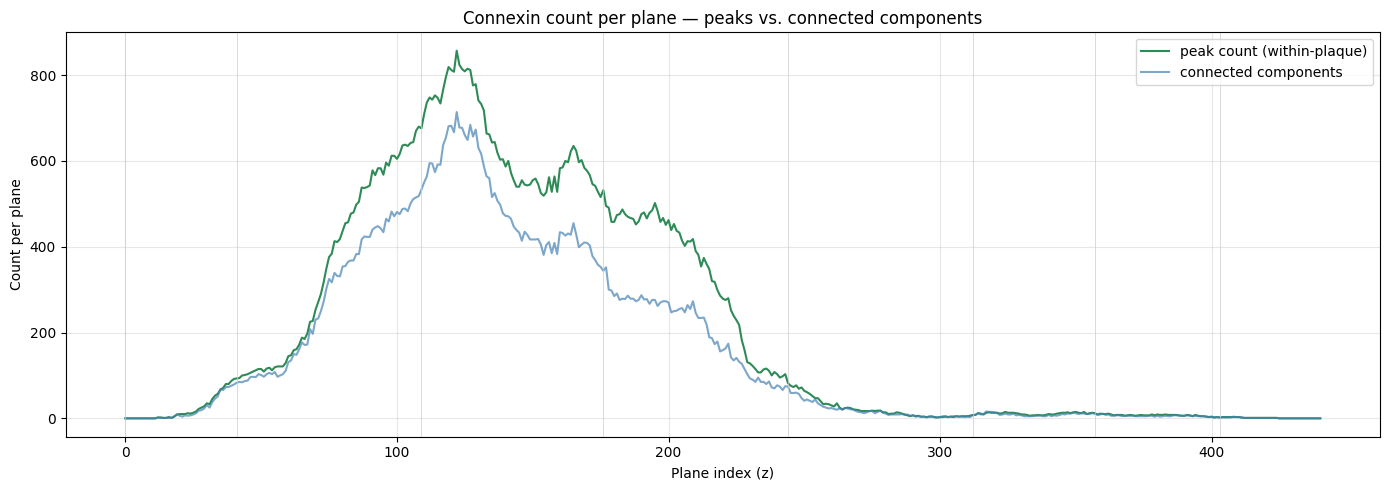

In [33]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(n_planes), peak_counts, color='seagreen', label='peak count (within-plaque)')
ax.plot(range(n_planes), counts, color='steelblue', alpha=0.7, label='connected components')
ax.set_xlabel('Plane index (z)')
ax.set_ylabel('Count per plane')
ax.set_title('Connexin count per plane — peaks vs. connected components')
for _, row in zone_samples.iterrows():
    ax.axvline(int(row['z_start']), color='0.8', lw=0.5)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'peak_vs_component_count.png', dpi=150, bbox_inches='tight')
plt.show()

Plaques with min distance 2 detected: 18


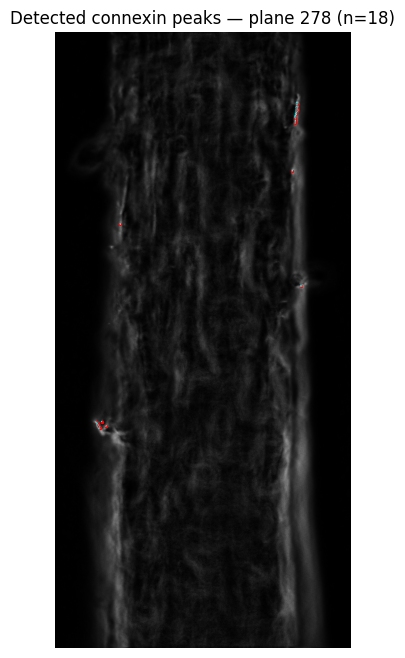

In [34]:
# peak overlay on the strongest-signal zone's sample plane
strong_plane = int(zone_samples.loc[zone_samples['sample_plane_intensity'].idxmax(), 'sample_plane'])
img01 = plane_to_float01(deconvolved[strong_plane])
coords, n = count_connexin_plaques_within_plaque(img01, seg[strong_plane], min_distance=MIN_DISTANCE)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(deconvolved[strong_plane], cmap='gray', vmin=DISP_VMIN, vmax=DISP_VMAX)
ax.contour(seg[strong_plane], [0.5], colors='cyan', linewidths=0.4)
ax.scatter(coords[:, 1], coords[:, 0], s=8, c='red', marker='.')  # coords are (y, x)
ax.set_title(f'Detected connexin peaks — plane {strong_plane} (n={n})')
ax.axis('off')
fig.savefig(RESULTS_DIR / 'peak_overlay_sample_plane.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Mean plaque size per plane

Mean connexin plaque size (2D cross-section area) per plane across the stack: foreground pixels
divided by the connected-component count. Shows whether typical plaque size changes with depth.

Mean plaque size over z=90:100: 3.483 µm²


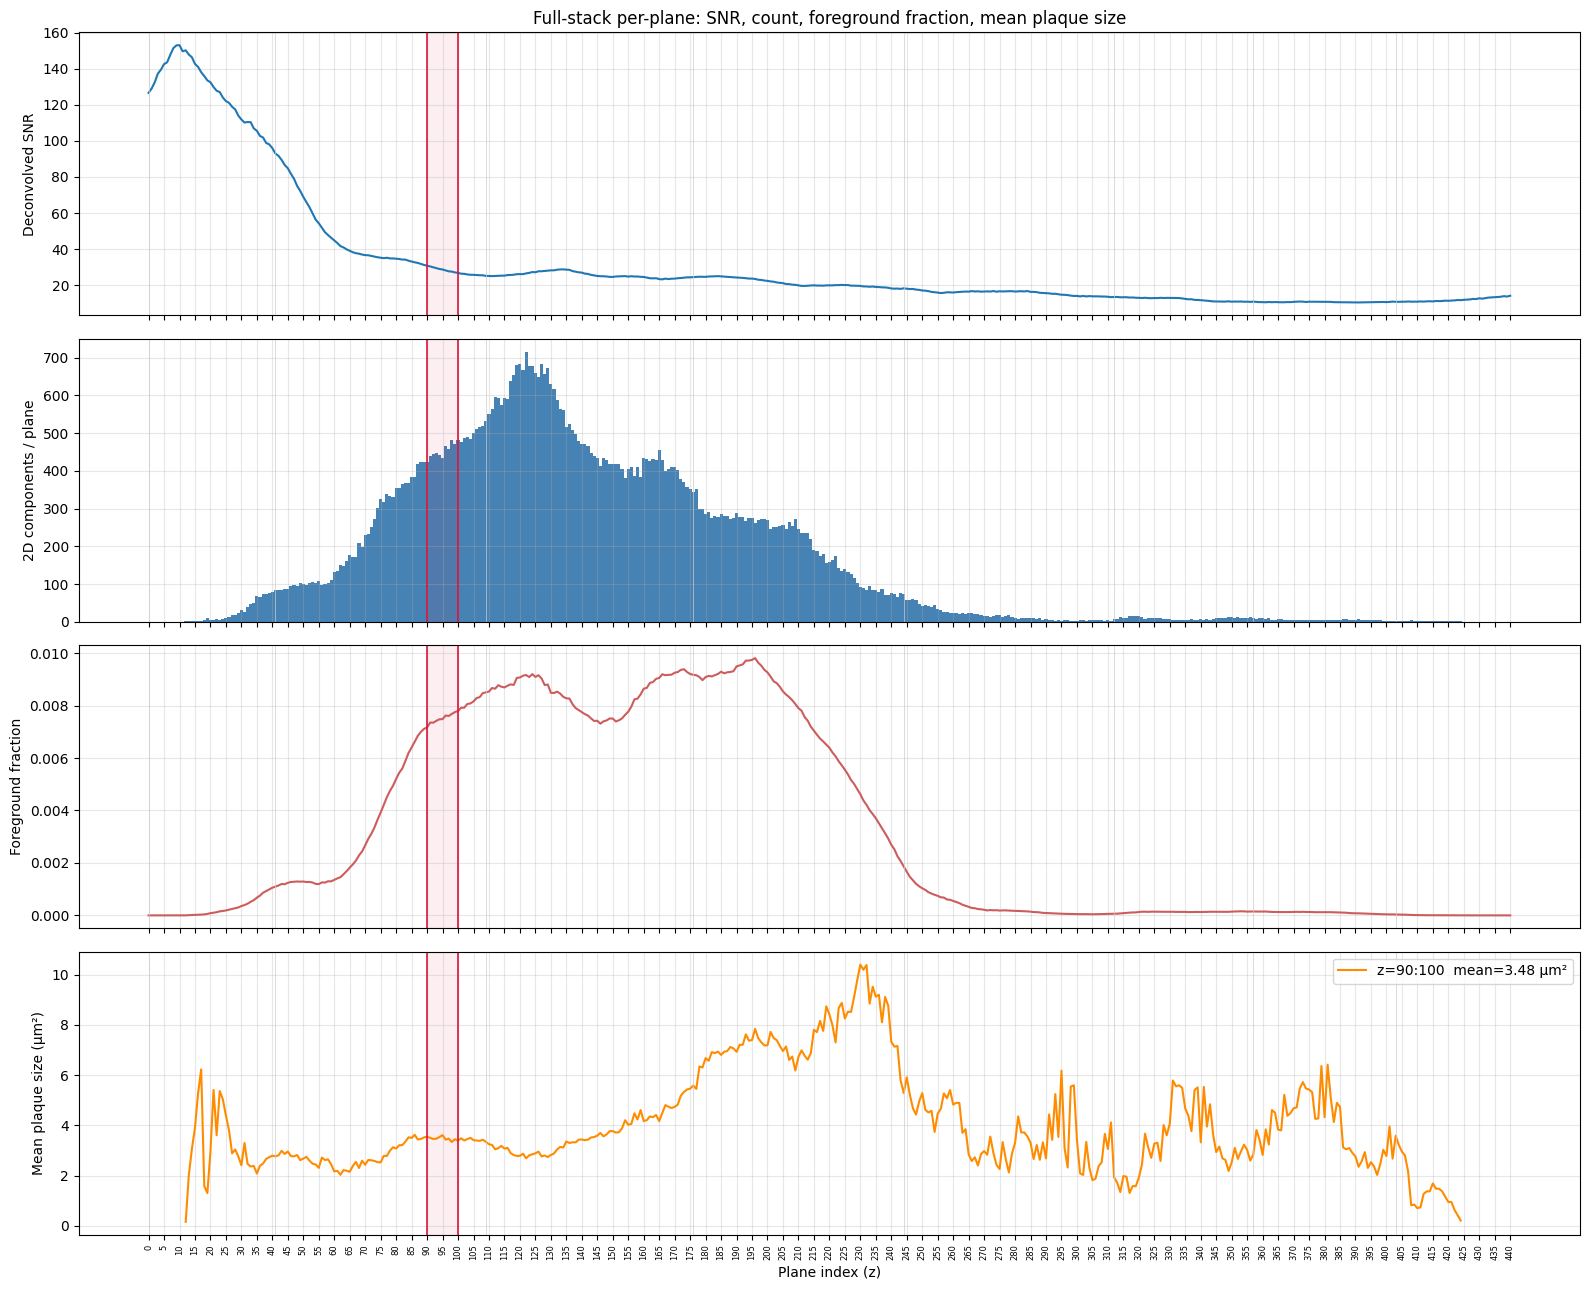

In [35]:
PIXEL_SIZE_UM = 0.325                 # lateral pixel size (matches src/localization.py)
PIXEL_AREA_UM2 = PIXEL_SIZE_UM ** 2

fg_px = np.array([int(seg[z].sum()) for z in range(n_planes)])
mean_size_px = np.where(counts > 0, fg_px / np.maximum(counts, 1), np.nan)  # mean component area (px)
mean_size_um2 = mean_size_px * PIXEL_AREA_UM2

# mean plaque size over the highlighted region (REGION_Z0:REGION_Z1 defined in cell 1)
region_mean_um2 = np.nanmean(mean_size_um2[REGION_Z0:REGION_Z1])
print(f"Mean plaque size over z={REGION_Z0}:{REGION_Z1}: {region_mean_um2:.3f} µm²")

# deconvolved SNR per plane, saved by 1_2, sliced to the cropped z-frame so it aligns
snr_path = BASE_DIR / 'data' / 'deconvolved_snr_per_plane.npy'
try:
    snr_full = np.load(snr_path)
    snr_deconv = snr_full if len(snr_full) == n_planes else snr_full[Z0:Z1]
    if len(snr_deconv) != n_planes:
        print(f"WARNING: SNR length {len(snr_full)} doesn't fit {n_planes}; resizing")
        snr_deconv = np.resize(snr_deconv, n_planes)
except FileNotFoundError:
    print(f"(no {snr_path.name}; run 1_2 first) — SNR panel will be empty")
    snr_deconv = np.full(n_planes, np.nan)

# 4 aligned panels: SNR, component count, foreground fraction, mean plaque size
fig, (ax0, ax1, ax2, ax3) = plt.subplots(4, 1, figsize=(16, 13), sharex=True)

ax0.plot(range(n_planes), snr_deconv, color='tab:blue')
ax0.set_ylabel('Deconvolved SNR')
ax0.set_title('Full-stack per-plane: SNR, count, foreground fraction, mean plaque size')

ax1.bar(range(n_planes), counts, width=1.0, color='steelblue', edgecolor='none')
ax1.set_ylabel('2D components / plane')

ax2.plot(range(n_planes), fgfrac, color='indianred')
ax2.set_ylabel('Foreground fraction')

ax3.plot(range(n_planes), mean_size_um2, color='darkorange',
         label=f'z={REGION_Z0}:{REGION_Z1}  mean={region_mean_um2:.2f} µm²')
ax3.set_ylabel('Mean plaque size (µm²)')
ax3.set_xlabel('Plane index (z)')
ax3.legend(loc='upper right')

for ax in (ax0, ax1, ax2, ax3):
    for _, row in zone_samples.iterrows():
        ax.axvline(int(row['z_start']), color='0.8', lw=0.5)
    ax.axvspan(REGION_Z0, REGION_Z1, color='crimson', alpha=0.07)
    ax.axvline(REGION_Z0, color='crimson', lw=1.2)
    ax.axvline(REGION_Z1, color='crimson', lw=1.2)
    ax.grid(alpha=0.3)

# finer x-axis: ticks every 5 planes
ax3.set_xticks(np.arange(0, n_planes, 5))
ax3.tick_params(axis='x', labelsize=6, rotation=90)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'per_plane_snr_count_fgfrac_meansize.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Napari overlay

Interactive view of the binary segmentation on top of the preprocessed (deconvolved) image.
Opens a Qt window, so it needs a local GUI session (won't render headless / on a remote server);
run in the `cardiac_analysis` env where napari is installed. If the window doesn't appear, run
`%gui qt` in a cell first. Use the viewer's 2D/3D toggle and z-slider to browse the stack.

In [ ]:
import napari

viewer = napari.Viewer()
viewer.add_image(
    deconvolved,
    name='Preprocessed (deconvolved)',
    colormap='gray',
    contrast_limits=(DISP_VMIN, DISP_VMAX),
)
viewer.add_image(
    seg.astype(np.uint8),
    name='Segmented connexin areas',
    colormap='green',
    opacity=0.5,
    blending='additive',
)

# XYZ orientation box
viewer.axes.visible = True
viewer.axes.colored = True   # X=red, Y=green, Z=blue
viewer.axes.dashed = False
viewer.axes.labels = True

## Summary

Reads the saved full-stack 2D Sauvola segmentation from `2_1_segmentation.ipynb` and QCs it per
depth zone; it does not recompute segmentation.

- **Section 4** reports 2D component count and foreground fraction per plane as mean ± SD over
  each zone's `z_start:z_end` range.
- **Section 5** shows both metrics across the whole stack, zone boundaries marked, to expose
  depth-dependent dropout (e.g. the near-empty deep planes seen in 2_1).
- **Section 6** adds a peak-based count (`count_connexin_plaques_within_plaque`) across all
  planes and compares it to the connected-component count.
- **Section 7** plots the mean plaque size (2D cross-section area) per plane across the stack.
- **Section 8** overlays the binary segmentation on the preprocessed image in an interactive
  napari viewer (local GUI only).

**Caveats:** both counts are per-plane 2D — component count merges touching plaques, peak count
splits them; neither is a unique 3D plaque count (use the 3D labeling in the localization
notebook). The peak count normalizes each plane to [0,1], so `threshold_abs=0.05` is
plane-relative (can amplify noise in low-signal deep planes), but peaks are restricted to the
segmented foreground via `labels=binary`. Segmentation params are inherited from `2_1`.